# **Diplomado IA: Inteligencia Artificial I - Parte 2**. <br> Práctico 1: Grafo cómputo, inicialización de pesos y funciones activación
---
---

**Profesores:**
- Carlos Aspillaga
- Gabriel Sepúlveda

**Ayudante:**
- Bianca del Solar
---
---

# **Instrucciones Generales**

El siguiente práctico se debe realizar de forma **individual**. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:**

El siguiente práctico cuanta con 2 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades correspondrán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.

**Fecha de entrega:** domingo 9 de noviembre de 2025, 23:59 hrs.

# **Funciones de Activación**

## Experimento 1: Explorando y visualizando las funciones de activación

Para esta etapa, vamos a explorar una función de activación, ver que valores posibles puede retornar y que gradientes puede devolver.

Primero vamos a definir una función de activacion, en este caso la `ReLU` (https://pytorch.org/docs/stable/nn.html#relu).

**Pytorch tip 1:** Para utilizar las funcionalidades de pytorch, debemos como primer paso imporate el paquete torch mediate: *import torch*

**Pytorch tip 2:** Para acceder a las funciones de activación, utilizaremos el módulo torch.nn. Las funciones de activación deberán ser instanciadas como un objeto de la clase en cuestión. Por ejemplo: *torch.nn.ReLU()*.

In [ ]:
import torch

activation_function = torch.nn.ReLU()

print(activation_function)

ReLU()


Luego vamos a utilizar dicha funcion para ver cual es la salida ante un valor positivo, el 0 y uno negativo.

**Pytorch tip:** Aquí es importante notar que utilizaremos un tipo de dato Tensor del framework pytorch. Como su nombre lo indica, este tipo de dato permite la creación y manejo de tensores, que son la unidad fundamental para el flujo de las operaciones matemáticas definidas en cualquier arquitectura. En el caso particular del ejemplo, crearemos tendores de 1 dimensión a partir de una lista de python.

In [ ]:
x = torch.Tensor([2])
positivo = activation_function(x)
print( 'Función evaluada en un valor positivo: %d' % (positivo))

x = torch.Tensor([0])
cero = activation_function(x)
print( 'Función evaluada en el cero: %d' % (cero))

x = torch.Tensor([-9])
negativo = activation_function(x)
print( 'Función evaluada en un valor negativo: %d' % (negativo))

Función evaluada en un valor positivo: 2
Función evaluada en el cero: 0
Función evaluada en un valor negativo: 0


Ahora vamos a graficar todos los valores posible que puede tomar un valor ente -10 y 10 cuando se le aplica una función de activación.

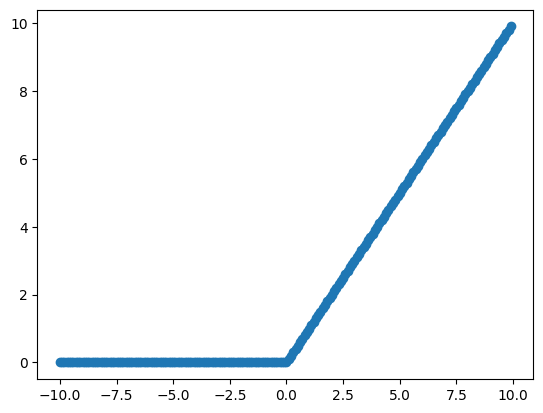

In [ ]:
import matplotlib.pyplot as plt

import numpy

X = []
Fx = []

# Recorremos todos los valores entre -10 a 10 con diferencia de 0.1 entre cada valor
for x in numpy.arange(-10, 10, 0.1):
    X.append(x)
    x = torch.Tensor([x])
    result = activation_function(x)
    Fx.append(float(result)) # convert Tensor() to float(), and append it into list

plt.scatter(X, Fx)

plt.show()

Ahora obtendremos el valor del gradiente (derivada) que devuelve la función de activación ReLU en su parte lineal. Para ello utilizaremos el método *backward* sobre el tensor de resultado (salida de ReLU), para iniciar la retro-propagación de los gradientes. El proceso de cálculo que hay detrás de este método, es el mismo analizado para el cálculo de gradientes mediante grafos de cómputo.

**Pytorch tip:** Aquí introduciremos un nuevo tipo de dato llamado *Variable*. Esta clase es simplemente un *wrapper* para de la clase Tensor, que permite mantener en memoria los datos necesarios para el cálculo de los gradientes y la estructura del grafo de cómputo. Para ello, es necesario entregar como argumento el tensor a utilizar, y el parámetro *requires_grad* con valor True. Para efectos operativos, *Variable* se comporta exactamente igual que *Tensor*.

In [ ]:
from torch.autograd import Variable

# Definimos el valor de entrada e indicamos que debe almacenar el gradiente
#x = Variable(torch.Tensor([2]), requires_grad=True)
x = torch.tensor([2.0], requires_grad=True)

result = activation_function(x)

# Aplicamos el paso "backward" para propagar los gradientes
# grad = df/dx * dx/dx
result.backward()

print( 'Función:    %s' % (activation_function))
print( 'Input:      %f' % (x))
print( 'Output:     %f' % (result))
print( 'Gradiente:  %f' % (x.grad))

Función:    ReLU()
Input:      2.000000
Output:     2.000000
Gradiente:  1.000000


/tmp/ipython-input-2728151121.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  print( 'Input:      %f' % (x))


Finalmente vamos a graficar todos los gradientes calculados al ingresar valores entre -10 y 10, o en otras palabras, vamos a graficar la derivada de la función de activación para dicho rango.

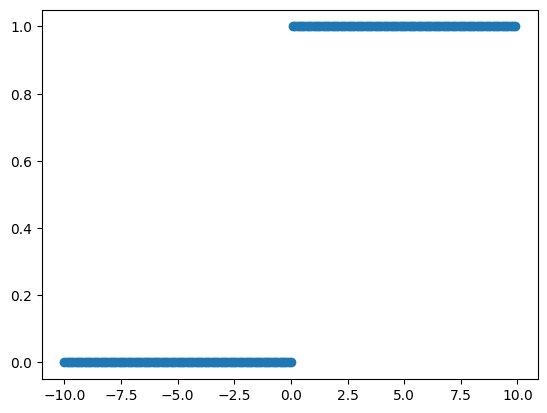

In [ ]:
X = []
gradiente = []

# Recorremos todos los valores entre -10 a 10 con diferencia de 0.1 entre cada valor
for x in numpy.arange(-10, 10, 0.1):
    X.append(x)
    x = Variable(torch.Tensor([x]), requires_grad=True)
    result = activation_function(x)
    result.backward()
    gradiente.append(float(x.grad))

plt.scatter(X, gradiente)
plt.show()

## Actividad 2.1

En el siguiente link: https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity se presenta un conjunto de funciones de activacion. Utilice la función `Sigmoid` para:
1. Confeccionar el gráfico de la función
2. Confeccionar el gráfico de su derivada

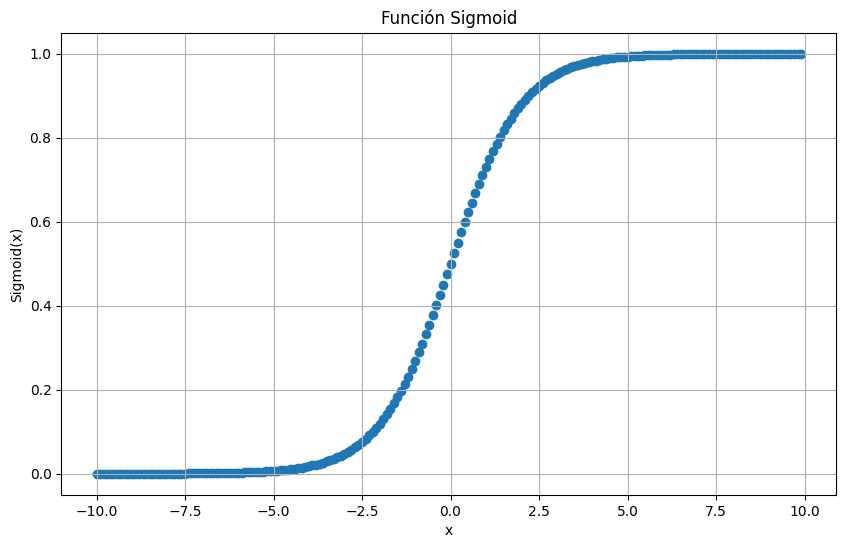

In [ ]:
# Código para confeccionar el gráfico de la función
import torch
import matplotlib.pyplot as plt
import numpy

# Definir la función de activación Sigmoid
activation_function = torch.nn.Sigmoid()

X = []
Fx = []

# Recorremos todos los valores entre -10 a 10 con diferencia de 0.1 entre cada valor
for x in numpy.arange(-10, 10, 0.1):
    X.append(x)
    x_tensor = torch.Tensor([x])
    result = activation_function(x_tensor)
    Fx.append(float(result))  # convert Tensor() to float(), and append it into list

plt.figure(figsize=(10, 6))
plt.scatter(X, Fx)
plt.title('Función Sigmoid')
plt.xlabel('x')
plt.ylabel('Sigmoid(x)')
plt.grid(True)
plt.show()




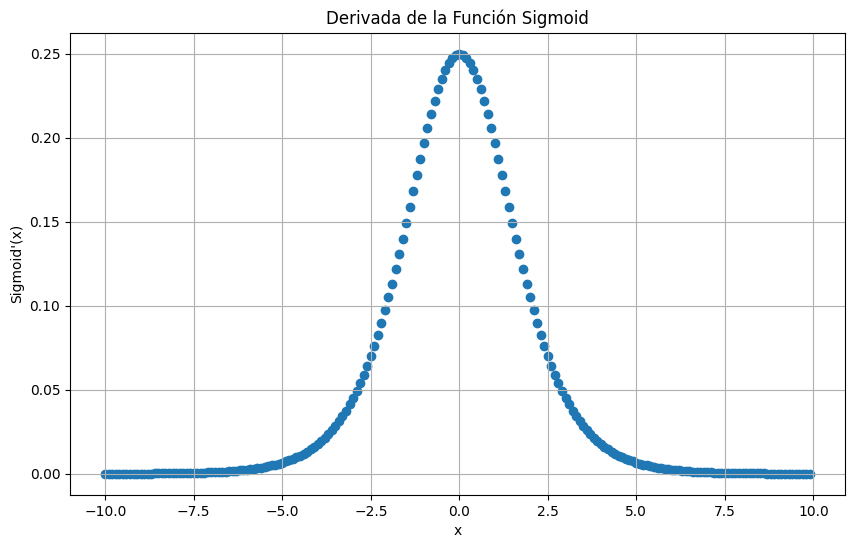

In [ ]:
# Código para confeccionar el gráfico de su derivada
import torch
import matplotlib.pyplot as plt
import numpy
from torch.autograd import Variable

# Definir la función de activación Sigmoid
activation_function = torch.nn.Sigmoid()

X = []
gradiente = []

# Recorremos todos los valores entre -10 a 10 con diferencia de 0.1 entre cada valor
for x in numpy.arange(-10, 10, 0.1):
    X.append(x)
    x_var = torch.tensor([x], requires_grad=True)
    result = activation_function(x_var)
    result.backward()
    gradiente.append(float(x_var.grad))

plt.figure(figsize=(10, 6))
plt.scatter(X, gradiente)
plt.title('Derivada de la Función Sigmoid')
plt.xlabel('x')
plt.ylabel("Sigmoid'(x)")
plt.grid(True)
plt.show()

## Actividad 2.2

Responda la siguiente pregunta.

**1** - Entre un modelo con función de activación ReLU y otro con función de activación Sigmoidal, ¿ Cual cree usted que aprendería más rápido ?. Justifique su respuesta apoyandose en los gráficos generados anteriormente.

**Respuesta**:

El modelo con función de activación **ReLU aprenderá más rápido** que el modelo con función Sigmoid, por las siguientes razones:

**1. Magnitud de los gradientes:**
- **ReLU**: En su parte positiva (x > 0), el gradiente es constante e igual a 1. Esto significa que durante la retropropagación, el gradiente se transmite sin atenuación.
- **Sigmoid**: Los gradientes son siempre menores a 0.25 (el máximo ocurre en x=0). Para valores alejados del origen, los gradientes se aproximan a 0, lo que hace que el aprendizaje sea muy lento.

**2. Problema del desvanecimiento del gradiente (Vanishing Gradient):**
- **Sigmoid**: Al observar el gráfico de su derivada, vemos que los gradientes son muy pequeños en los extremos (cercanos a 0 cuando |x| > 5). En redes profundas, al multiplicar estos gradientes pequeños en cada capa durante la retropropagación, el gradiente se hace prácticamente 0, deteniendo el aprendizaje de las capas iniciales.
- **ReLU**: No sufre este problema en su región positiva, ya que mantiene un gradiente constante de 1.

**3. Eficiencia computacional:**
- **ReLU**: Es computacionalmente más eficiente (solo requiere comparar con 0).
- **Sigmoid**: Requiere calcular una exponencial, lo que es más costoso.

**Conclusión:** ReLU permite un aprendizaje más rápido y eficiente, especialmente en redes neuronales profundas, debido a que mantiene gradientes más grandes y evita el problema del desvanecimiento del gradiente.

Si quedaste con ganas de explorar otras funciones de activacion y visualizar sus derivadas. Recomendamos la siguiente página: https://dashee87.github.io/deep%20learning/visualising-activation-functions-in-neural-networks/

# **Inicialización de Pesos**

En la siguiente sección analizaremos el afecto que tiene el criterio de inicialización de pesos escogido, sobre el proceso de entrenamiento de una red neuronal profunda.

Para ello, crearemos una red neuronal de 10 capas, que recibirá como entrada un vector de 2 dimensiones, y entregará a la salida un único valor. Esta red será construida sin utilizar función de activación en ninguna de sus capas, con el objetivo de medir de forma aislada el efecto de los valores iniciales de los pesos. La siguiente figura, muestra un esquema de la red neuronal diseñada:

<img src="https://imgur.com/O9acV99.png"/>




## Experimento 1: Inicialización con valor constante

Antes de comenzar, importaremos los paquetes necesarios para el desarrollo de esta sección. Con ellos, definiremos la función *plot_variable* que nos permitirá graficar de forma sencilla el valor de los gradientes, y la función *fit*, que implementará el loop de entrenamiento entregando como único valor de entrada el vector $[0.5, 0.5]$, para la predicción del valor 1.

Por ahora, no nos enfocaremos en su implementación.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
def plot_variable( grads, varname ):
  plt.figure( figsize=(9, 6) )
  ax = plt.axes()
  ax.set_xlabel( 'Training step' )
  ax.set_ylabel( varname )
  ax.plot( grads )
  ax.update_datalim( list( zip( range(len(grads)), grads ) ) )
  ax.autoscale()

In [ ]:
def fit( model ):
  mse_lossfunc = nn.MSELoss()
  optimizer = optim.Adam( model.parameters(), lr = 1e-4 )
  x = torch.Tensor( [0.5, 0.5] )
  y = torch.Tensor( [1] )
  gradients = list()
  loss_seq = list()
  for i in range( 200 ):
    p = model( x )
    loss_value = mse_lossfunc( p, y )
    optimizer.zero_grad()
    loss_value.backward()
    optimizer.step()
    gradients.append( model.layer_0.weight.grad[0,:] )
    loss_seq.append( loss_value.item() )
  gradients = torch.stack( gradients )
  loss_seq = torch.Tensor( loss_seq )
  plot_variable( gradients[:,0], 'Gradient' )
  plot_variable( loss_seq, 'Loss' )

En el siguiente código hemos definido el modelo *DeepNN*. Éste implementa una red neuronal con 9 capas ocultas de 2 neuronas, y una capa de salida de 1 neurona, y sin utilizar función de activación.

Cada capa es definida mediante la creación de un objeto de la clase *Linear* de torch, las cuales son almacenadas dentro de los atributos de nombre *layer_x*. Una vez creadas las 10 capas, utilizaremos la función *init.constant_* de torch para inicializar los pesos de cada capa a un valor constante, el cual es definido por un parámetro del constructor de la clase.

In [ ]:
class DeepNN( nn.Module ):

  def __init__( self, weights_initial_value ):
    super( DeepNN, self ).__init__()
    self.layer_0 = torch.nn.Linear( 2, 2 )
    self.layer_1 = torch.nn.Linear( 2, 2 )
    self.layer_2 = torch.nn.Linear( 2, 2 )
    self.layer_3 = torch.nn.Linear( 2, 2 )
    self.layer_4 = torch.nn.Linear( 2, 2 )
    self.layer_5 = torch.nn.Linear( 2, 2 )
    self.layer_6 = torch.nn.Linear( 2, 2 )
    self.layer_7 = torch.nn.Linear( 2, 2 )
    self.layer_8 = torch.nn.Linear( 2, 2 )
    self.layer_9 = torch.nn.Linear( 2, 1 )
    torch.nn.init.constant_( self.layer_0.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_1.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_2.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_3.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_4.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_5.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_6.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_7.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_8.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_9.weight.data, weights_initial_value )

  def forward( self, x ):
    x = self.layer_0(x)
    x = self.layer_1(x)
    x = self.layer_2(x)
    x = self.layer_3(x)
    x = self.layer_4(x)
    x = self.layer_5(x)
    x = self.layer_6(x)
    x = self.layer_7(x)
    x = self.layer_8(x)
    x = self.layer_9(x)
    return x

### Inicialización de pesos con valores menor a 1

Nuestro primer experimento consistirá en iniciazar la red con todos sus pesos con un valor menor que uno. En particular, el valor escogido es 0.1.

In [ ]:
model = DeepNN( 0.1 )
print(model.layer_0.weight.data)

tensor([[0.1000, 0.1000],
        [0.1000, 0.1000]])


Ahora, veamos que pasa con los gradientes y la pérdida al entrenar el modelo.

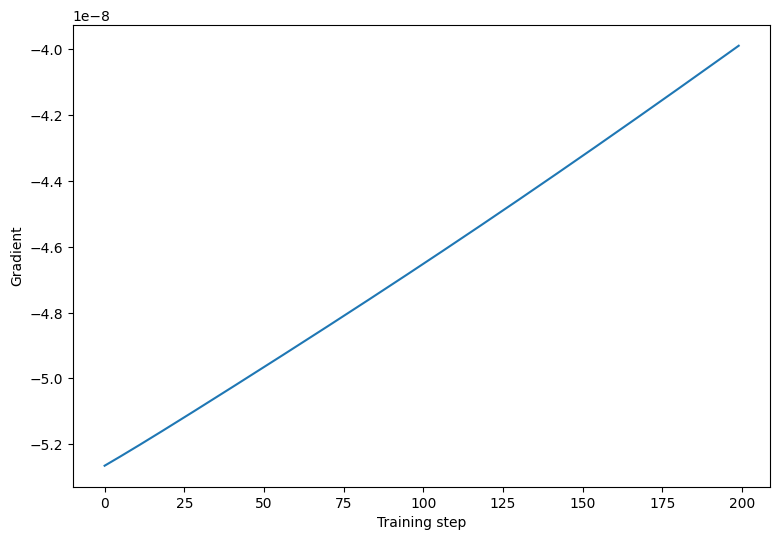

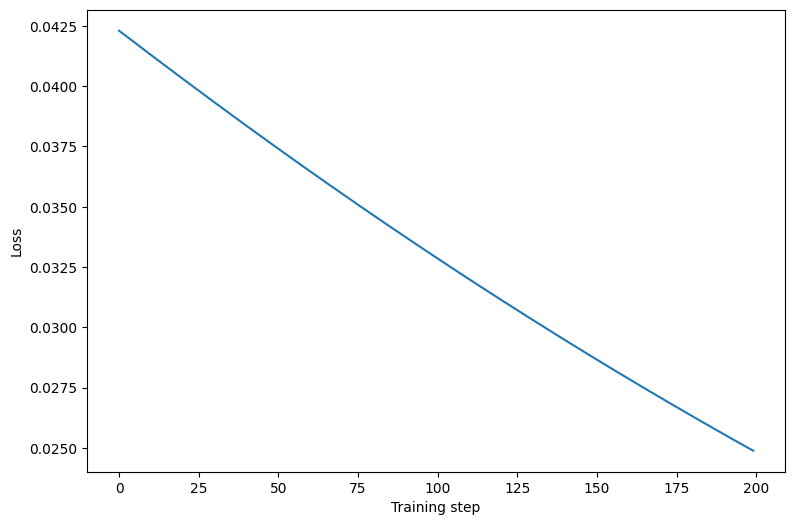

In [ ]:
fit(model)

### Inicialización de pesos con valores mayor a 1

En el presente experimento, inicializaremos la red con todos sus pesos con un valor mayor a 1. En particular, el valor escogido es 1.5.

In [ ]:
model = DeepNN( 1.5 )
print(model.layer_0.weight.data)

tensor([[1.5000, 1.5000],
        [1.5000, 1.5000]])


Ahora, veamos que pasa con los gradientes y la pérdida al entrenar el modelo.

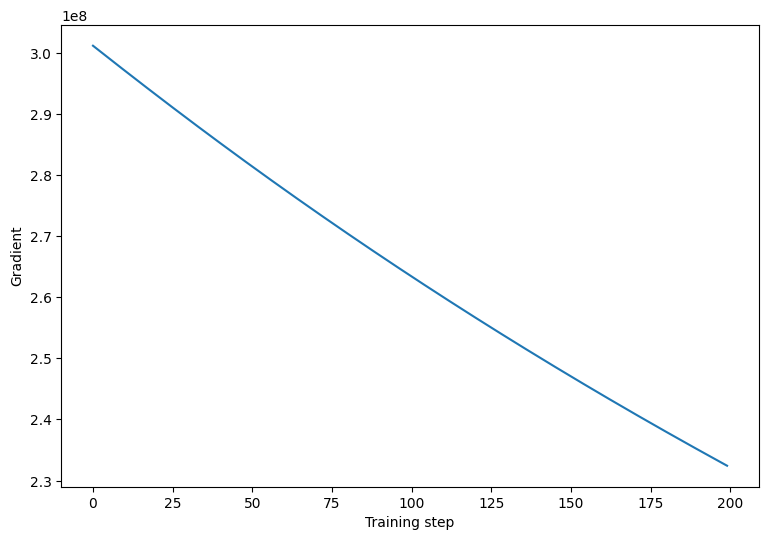

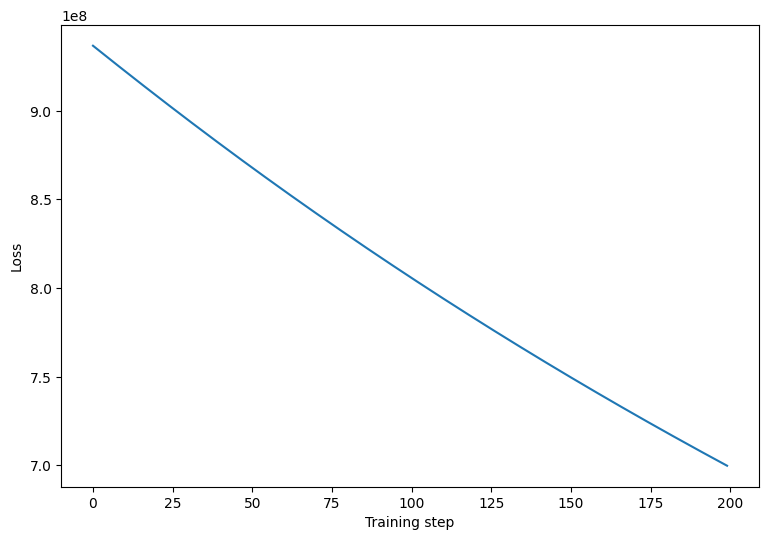

In [ ]:
fit(model)

## Actividades

### Actividad 3.1

**Respuesta:**

El fenómeno observado se llama **Vanishing Gradient** o **Desvanecimiento del Gradiente**.

Al inicializar los pesos con valores menores a 1 (en este caso 0.1), los gradientes se vuelven extremadamente pequeños (del orden de 1e-7) durante la retropropagación. Esto ocurre porque en cada capa de la red profunda, el gradiente se multiplica por el valor del peso (0.1), y al tener 10 capas, el gradiente se reduce exponencialmente: (0.1)^10 = 1e-10.

Como resultado, los gradientes son prácticamente cero, lo que hace que:
- Los pesos no se actualicen significativamente
- El aprendizaje sea extremadamente lento o prácticamente nulo
- Las capas iniciales de la red no aprendan

¿ Como se llama el fenómeno observado al inicializar los pesos con valores menor a 1 ?

**Respuesta:**

El fenómeno observado se llama **Exploding Gradient** o **Explosión del Gradiente**.

Al inicializar los pesos con valores mayores a 1 (en este caso 1.5), los gradientes crecen exponencialmente durante la retropropagación. En cada capa, el gradiente se multiplica por el valor del peso (1.5), y al tener 10 capas, el gradiente crece de forma explosiva: (1.5)^10 ≈ 57.67, llegando a valores del orden de 1e8 en los gráficos.

Como resultado de este fenómeno:
- Los gradientes se vuelven extremadamente grandes
- Las actualizaciones de los pesos son desproporcionadas
- El entrenamiento se vuelve inestable
- Los valores de pérdida pueden divergir o volverse NaN (Not a Number)
- El modelo no converge a una solución óptima

¿ Como se llama el fenómeno observado al inicializar los pesos con valores mayor a 1 ?

**Respuesta:**

El fenómeno observado se llama **Exploding Gradient** o **Explosión del Gradiente**.

Al inicializar los pesos con valores mayores a 1 (en este caso 1.5), los gradientes crecen exponencialmente durante la retropropagación. En cada capa, el gradiente se multiplica por el valor del peso (1.5), y al tener 10 capas, el gradiente crece de forma explosiva: (1.5)^10 ≈ 57.67, llegando a valores del orden de 1e8 en los gráficos.

Como resultado de este fenómeno:
- Los gradientes se vuelven extremadamente grandes
- Las actualizaciones de los pesos son desproporcionadas
- El entrenamiento se vuelve inestable
- Los valores de pérdida pueden divergir o volverse NaN (Not a Number)
- El modelo no converge a una solución óptima

### Actividad 3.2

Repita el ejercicio anterior, pero esta vez, incializando los pesos a través del método de Xavier Glorot.

Para ello deberá re-definir el modelo y reemplazar la función de inicialización por la función *torch.nn.init.xavier_uniform_*. Para mayor detalle sobre esta función, visite el sitio: [Pytorch Xavier Uniform](https://pytorch.org/docs/stable/nn.init.html#torch.nn.init.xavier_uniform_)

In [ ]:
# Ingrese el código para el modelo de su red
class DeepNN_Xavier(nn.Module):
    def __init__(self):
        super(DeepNN_Xavier, self).__init__()
        self.layer_0 = torch.nn.Linear(2, 2)
        self.layer_1 = torch.nn.Linear(2, 2)
        self.layer_2 = torch.nn.Linear(2, 2)
        self.layer_3 = torch.nn.Linear(2, 2)
        self.layer_4 = torch.nn.Linear(2, 2)
        self.layer_5 = torch.nn.Linear(2, 2)
        self.layer_6 = torch.nn.Linear(2, 2)
        self.layer_7 = torch.nn.Linear(2, 2)
        self.layer_8 = torch.nn.Linear(2, 2)
        self.layer_9 = torch.nn.Linear(2, 1)

        # Inicialización con Xavier Glorot (Uniform)
        torch.nn.init.xavier_uniform_(self.layer_0.weight.data)
        torch.nn.init.xavier_uniform_(self.layer_1.weight.data)
        torch.nn.init.xavier_uniform_(self.layer_2.weight.data)
        torch.nn.init.xavier_uniform_(self.layer_3.weight.data)
        torch.nn.init.xavier_uniform_(self.layer_4.weight.data)
        torch.nn.init.xavier_uniform_(self.layer_5.weight.data)
        torch.nn.init.xavier_uniform_(self.layer_6.weight.data)
        torch.nn.init.xavier_uniform_(self.layer_7.weight.data)
        torch.nn.init.xavier_uniform_(self.layer_8.weight.data)
        torch.nn.init.xavier_uniform_(self.layer_9.weight.data)

    def forward(self, x):
        x = self.layer_0(x)
        x = self.layer_1(x)
        x = self.layer_2(x)
        x = self.layer_3(x)
        x = self.layer_4(x)
        x = self.layer_5(x)
        x = self.layer_6(x)
        x = self.layer_7(x)
        x = self.layer_8(x)
        x = self.layer_9(x)
        return x

In [ ]:
# Ingrese el código para crear una instancia de su modelo
# Ingrese el código para crear una instancia de su modelo
model_xavier = DeepNN_Xavier()
print("Pesos de la primera capa con inicialización Xavier:")
print(model_xavier.layer_0.weight.data)

Pesos de la primera capa con inicialización Xavier:
tensor([[-0.4580, -1.2073],
        [-0.0911, -1.1752]])


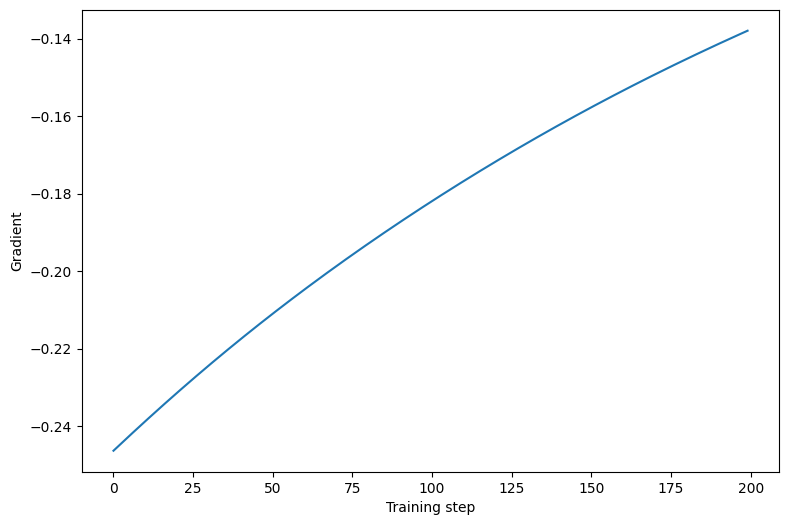

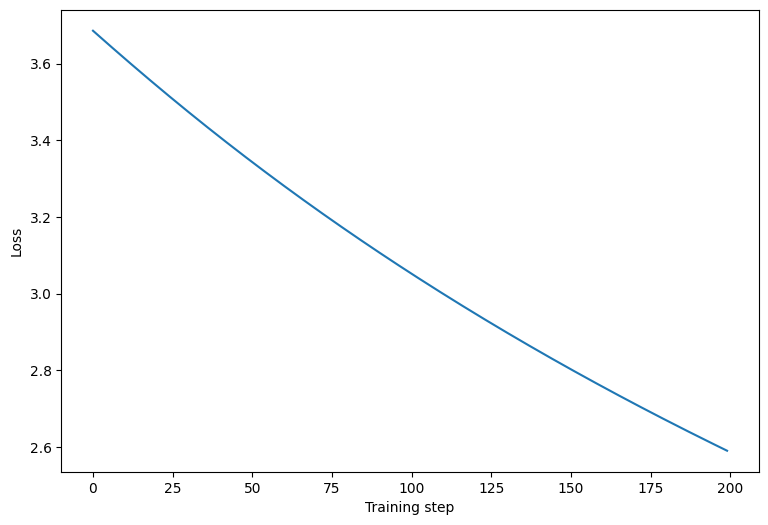

In [ ]:
# Ingrese el código que llama a la función fit, entregando su modelo como parámetro
fit(model_xavier)

¿ Qué efecto puede ver de la aplicación de este nuevo método de inicialización de pesos ?

**Respuesta:**

Al aplicar el método de inicialización Xavier Glorot se observan los siguientes efectos positivos:

1. **Gradientes estables**: Los gradientes se mantienen en un rango razonable y estable durante todo el entrenamiento (no son ni demasiado pequeños ni demasiado grandes), típicamente en el orden de magnitud cercano a 1.

2. **Convergencia efectiva**: La función de pérdida (Loss) disminuye de forma consistente y suave durante el entrenamiento, lo que indica que el modelo está aprendiendo correctamente.

3. **Sin problemas de vanishing o exploding gradient**: A diferencia de las inicializaciones con valores constantes (0.1 o 1.5), no se observa ni desvanecimiento ni explosión de gradientes.

4. **Entrenamiento eficiente**: El modelo converge más rápidamente hacia una solución óptima, aprovechando mejor cada iteración del proceso de entrenamiento.

5. **Comportamiento balanceado**: Todas las capas de la red pueden aprender de manera efectiva, ya que la señal del gradiente se propaga adecuadamente a través de toda la arquitectura.

¿ A que se deben los efectos observados ?

**Respuesta:**

Los efectos positivos observados se deben al **diseño matemático del método de Xavier Glorot**, que busca mantener la varianza de las activaciones y gradientes constante a través de todas las capas de la red. Específicamente:

**1. Principio de Xavier:**
El método inicializa los pesos siguiendo una distribución uniforme en el rango:
$$W \sim U\left[-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}}\right]$$

Donde $n_{in}$ es el número de neuronas de entrada y $n_{out}$ es el número de neuronas de salida de cada capa.

**2. Balance de varianza:**
- Xavier garantiza que la varianza de las activaciones se mantenga aproximadamente igual en todas las capas durante la propagación hacia adelante.
- También asegura que la varianza de los gradientes se mantenga estable durante la retropropagación.

**3. Prevención de problemas:**
- **Evita vanishing gradient**: Los pesos no son demasiado pequeños, por lo que los gradientes no se desvanecen al multiplicarse capa tras capa.
- **Evita exploding gradient**: Los pesos no son demasiado grandes, por lo que los gradientes no explotan exponencialmente.

**4. Adaptabilidad:**
Al considerar tanto $n_{in}$ como $n_{out}$, el método se adapta automáticamente a la arquitectura específica de cada capa, manteniendo un flujo de información óptimo independientemente del tamaño de las capas.

**Conclusión:** Xavier Glorot es una técnica de inicialización diseñada específicamente para redes profundas sin función de activación (o con activaciones lineales), equilibrando la magnitud de los pesos para mantener gradientes saludables y permitir un entrenamiento efectivo.